Import lib


In [1]:
%matplotlib inline

from pathlib import Path
import random

from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display

Declare the Path

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATASET_DIR = PROJECT_ROOT / "data" / "raw" / "BCCD"
IMAGE_DIR = DATASET_DIR / "train" / "images"
LABEL_DIR = DATASET_DIR / "train" / "labels"
DATA_YAML = DATASET_DIR / "data.yaml"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_DIR:", DATASET_DIR)
print("IMAGE_DIR:", IMAGE_DIR)
print("LABEL_DIR:", LABEL_DIR)
print("DATA_YAML:", DATA_YAML)

print("\nIMAGE_DIR exists:", IMAGE_DIR.exists())
print("LABEL_DIR exists:", LABEL_DIR.exists())
print("DATA_YAML exists:", DATA_YAML.exists())

PROJECT_ROOT: d:\IT\AI Microscope Blood Cell Detection System
DATASET_DIR: d:\IT\AI Microscope Blood Cell Detection System\data\raw\BCCD
IMAGE_DIR: d:\IT\AI Microscope Blood Cell Detection System\data\raw\BCCD\train\images
LABEL_DIR: d:\IT\AI Microscope Blood Cell Detection System\data\raw\BCCD\train\labels
DATA_YAML: d:\IT\AI Microscope Blood Cell Detection System\data\raw\BCCD\data.yaml

IMAGE_DIR exists: True
LABEL_DIR exists: True
DATA_YAML exists: True


Collect image Path

In [3]:
def collect_image_paths(image_dir):
    """Collect image paths from a folder with common image extensions."""
    image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]

    image_paths = []
    for extension in image_extensions:
        image_paths.extend(image_dir.glob(extension))

    return sorted(image_paths)


image_paths = collect_image_paths(IMAGE_DIR)

print("Number of images:", len(image_paths))

if len(image_paths) > 0:
    print("First image:", image_paths[0])
else:
    raise FileNotFoundError(f"No images found in: {IMAGE_DIR}")

Number of images: 1530
First image: d:\IT\AI Microscope Blood Cell Detection System\data\raw\BCCD\train\images\BloodImage_00001_jpg.rf.1a3206b15602db1d97193162a50bd001.jpg


Load class name

In [ ]:
def load_class_names(data_yaml_path):
    """Load class names from YOLO data.yaml.

    If the data.yaml file cannot be read, the function will use the default BCCD class.
    BCCD typically has three classes: Platelets, RBC, and WBC.
    """
    default_class_names = ["Platelets", "RBC", "WBC"]

    if not data_yaml_path.exists():
        print("data.yaml not found. Using default class names:", default_class_names)
        return default_class_names

    try:
        import yaml

        with open(data_yaml_path, "r", encoding="utf-8") as file:
            data = yaml.safe_load(file)

        names = data.get("names", default_class_names)

        if isinstance(names, dict):
            names = [names[index] for index in sorted(names.keys())]

        print("Class names loaded from data.yaml:", names)
        return names

    except Exception as error:
        print("Could not read data.yaml:", error)
        print("Using default class names:", default_class_names)
        return default_class_names


CLASS_NAMES = load_class_names(DATA_YAML)
print("CLASS_NAMES:", CLASS_NAMES)

Class names loaded from data.yaml: ['Platelets', 'RBC', 'WBC']
CLASS_NAMES: ['Platelets', 'RBC', 'WBC']


Function to read YOLO label

In [5]:
def read_yolo_labels(label_path):
    """Read YOLO annotation file.

    YOLO format per line:
    class_id x_center y_center width height

    All box values are normalized between 0 and 1.
    """
    boxes = []

    if not label_path.exists():
        print(f"Label file not found: {label_path}")
        return boxes

    with open(label_path, "r", encoding="utf-8") as file:
        lines = file.readlines()

    for line_number, line in enumerate(lines, start=1):
        line = line.strip()

        if line == "":
            continue

        parts = line.split()

        if len(parts) != 5:
            print(f"Invalid label line {line_number}: {line}")
            continue

        try:
            class_id = int(parts[0])
            x_center = float(parts[1])
            y_center = float(parts[2])
            width = float(parts[3])
            height = float(parts[4])

            boxes.append({
                "class_id": class_id,
                "x_center": x_center,
                "y_center": y_center,
                "width": width,
                "height": height,
            })

        except ValueError:
            print(f"Could not parse label line {line_number}: {line}")
            continue

    return boxes

Convert YOLO box to pixel Box


In [6]:
def yolo_to_pixel_box(box, image_width, image_height):
    """Convert normalized YOLO box to pixel coordinates."""
    x_center = box["x_center"] * image_width
    y_center = box["y_center"] * image_height
    box_width = box["width"] * image_width
    box_height = box["height"] * image_height

    x1 = x_center - box_width / 2
    y1 = y_center - box_height / 2

    return x1, y1, box_width, box_height

visualize function

In [7]:
def visualize_annotation(image_path, label_path, class_names=None, figsize=(8, 8), show=True):
    """Visualize an image with YOLO bounding boxes."""
    if class_names is None:
        class_names = CLASS_NAMES

    image = Image.open(image_path).convert("RGB")
    image_width, image_height = image.size

    boxes = read_yolo_labels(label_path)

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image)

    for box in boxes:
        class_id = box["class_id"]
        x1, y1, box_width, box_height = yolo_to_pixel_box(box, image_width, image_height)

        rect = patches.Rectangle(
            (x1, y1),
            box_width,
            box_height,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        ax.add_patch(rect)

        if 0 <= class_id < len(class_names):
            label_name = class_names[class_id]
        else:
            label_name = f"class_{class_id}"

        ax.text(
            x1,
            max(y1 - 5, 0),
            label_name,
            fontsize=10,
            color="yellow",
            bbox=dict(facecolor="black", alpha=0.6),
        )

    ax.set_title(f"{image_path.name} | boxes: {len(boxes)}")
    ax.axis("off")
    plt.tight_layout()

    if show:
        display(fig)
        plt.close(fig)

    return fig

Choose a random image and visualize it

Image: d:\IT\AI Microscope Blood Cell Detection System\data\raw\BCCD\train\images\BloodImage_00139_jpg.rf.b81dfc2638216c320d7fe1b2524e3396.jpg
Label: d:\IT\AI Microscope Blood Cell Detection System\data\raw\BCCD\train\labels\BloodImage_00139_jpg.rf.b81dfc2638216c320d7fe1b2524e3396.txt
Image exists: True
Label exists: True
Number of boxes: 12
First boxes: [{'class_id': 1, 'x_center': 0.44471153846153844, 'y_center': 0.11899038461538461, 'width': 0.17307692307692307, 'height': 0.23557692307692307}, {'class_id': 1, 'x_center': 0.49158653846153844, 'y_center': 0.5805288461538461, 'width': 0.17548076923076922, 'height': 0.23076923076923078}, {'class_id': 1, 'x_center': 0.203125, 'y_center': 0.5829326923076923, 'width': 0.17548076923076922, 'height': 0.23076923076923078}, {'class_id': 1, 'x_center': 0.24759615384615385, 'y_center': 0.2848557692307692, 'width': 0.23076923076923078, 'height': 0.3485576923076923}, {'class_id': 1, 'x_center': 0.84375, 'y_center': 0.7560096153846154, 'width': 0.2

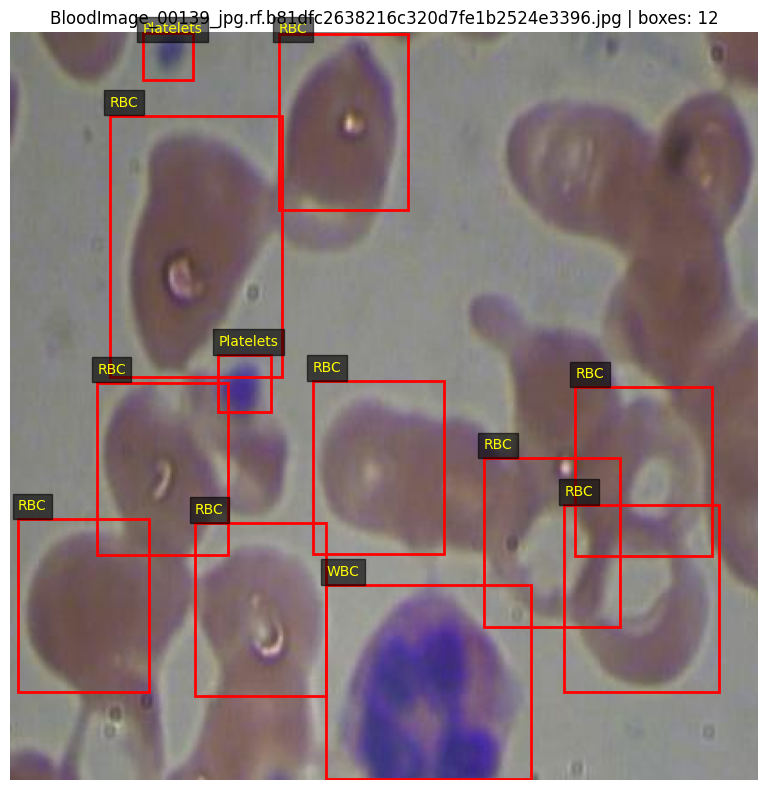

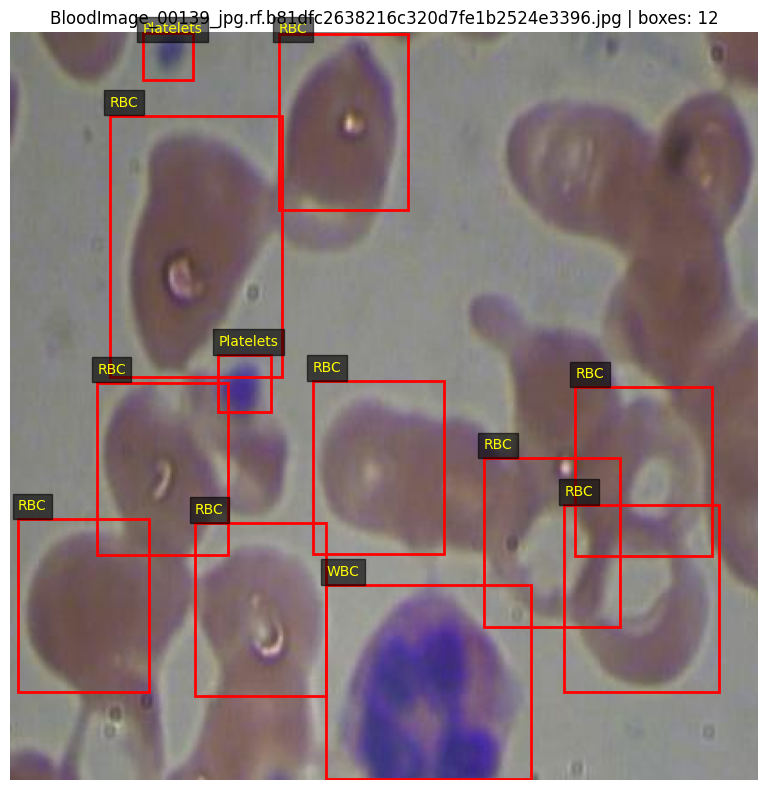

In [8]:
sample_image = random.choice(image_paths)
sample_label = LABEL_DIR / f"{sample_image.stem}.txt"

print("Image:", sample_image)
print("Label:", sample_label)
print("Image exists:", sample_image.exists())
print("Label exists:", sample_label.exists())

boxes = read_yolo_labels(sample_label)
print("Number of boxes:", len(boxes))
print("First boxes:", boxes[:5])

visualize_annotation(sample_image, sample_label)

Visualize multiple random images

--------------------------------------------------------------------------------
Image: BloodImage_00222_jpg.rf.9ed0898dc33e83c49f817f3683e12af3.jpg
Label exists: True
Number of boxes: 14


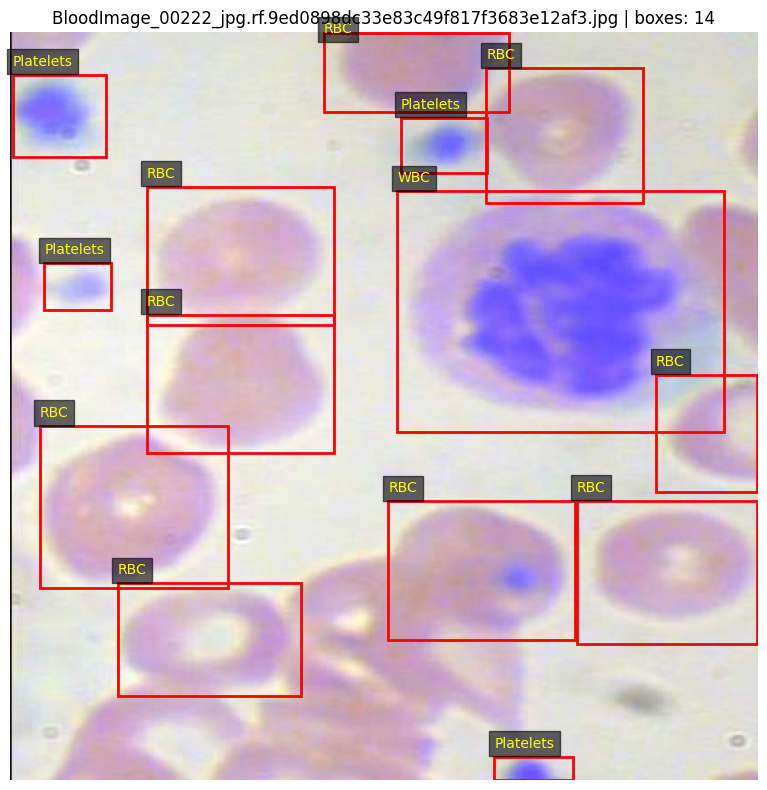

--------------------------------------------------------------------------------
Image: BloodImage_00184_jpg.rf.bbdaff1ccf981b24fe543cf42e5be191.jpg
Label exists: True
Number of boxes: 10


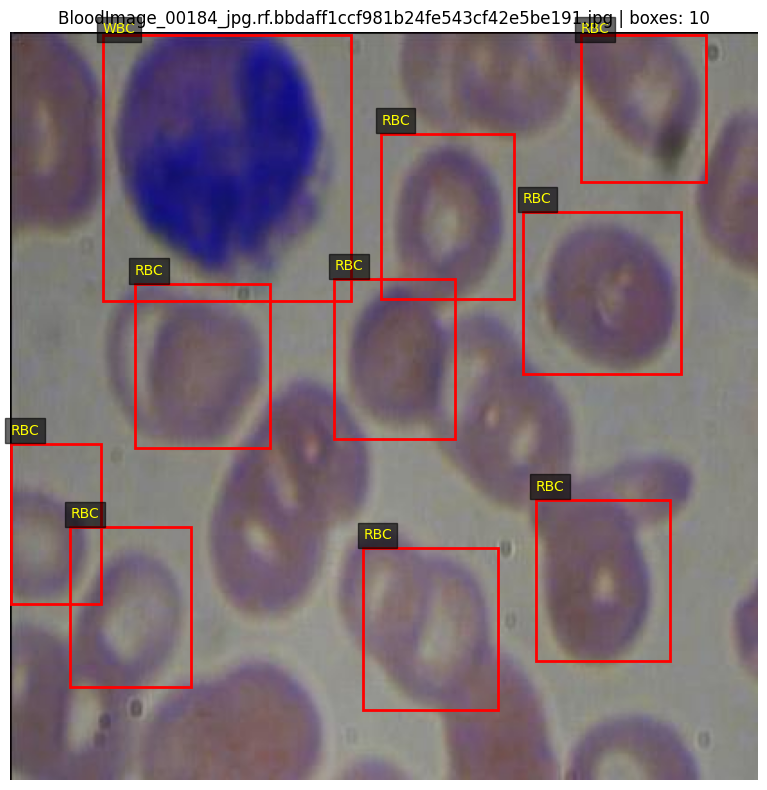

--------------------------------------------------------------------------------
Image: BloodImage_00262_jpg.rf.bfd064219a8e4c981773c44ab1399732.jpg
Label exists: True
Number of boxes: 10


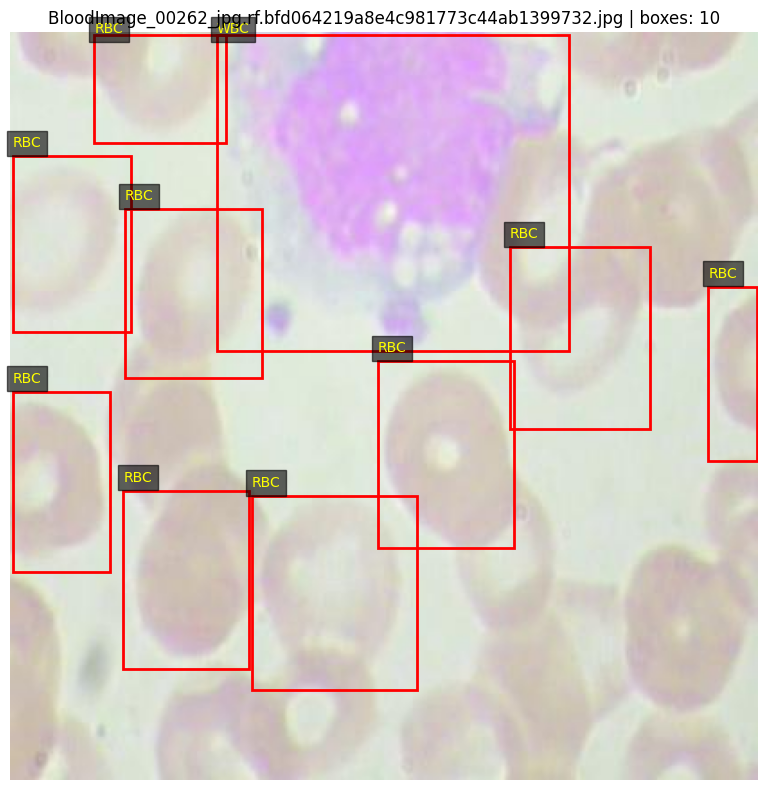

In [9]:
def visualize_random_annotations(image_paths, label_dir, number_of_images=3):
    """Visualize multiple random annotated images."""
    number_of_images = min(number_of_images, len(image_paths))
    selected_images = random.sample(image_paths, number_of_images)

    for image_path in selected_images:
        label_path = label_dir / f"{image_path.stem}.txt"

        print("-" * 80)
        print("Image:", image_path.name)
        print("Label exists:", label_path.exists())
        print("Number of boxes:", len(read_yolo_labels(label_path)))

        visualize_annotation(image_path, label_path)


visualize_random_annotations(image_paths, LABEL_DIR, number_of_images=3)

save annotated image

In [10]:
OUTPUT_DIR = PROJECT_ROOT / "reports" / "figures" / "annotations"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sample_output_path = OUTPUT_DIR / f"annotated_{sample_image.stem}.png"

fig = visualize_annotation(sample_image, sample_label, show=False)
fig.savefig(sample_output_path, dpi=150, bbox_inches="tight")
plt.close(fig)

print("Saved annotated image to:", sample_output_path)

Saved annotated image to: d:\IT\AI Microscope Blood Cell Detection System\reports\figures\annotations\annotated_BloodImage_00139_jpg.rf.b81dfc2638216c320d7fe1b2524e3396.png
